In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-python.tar.gz
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/batches.meta
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/test_batch
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_3
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_5
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_4
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/readme.html


In [6]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

resnet_model = resnet18(weights=weights)

print("Pretrained ResNet-18 loaded")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s] 


Pretrained ResNet-18 loaded


In [7]:
import torch.nn as nn

resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    10
)

print(resnet_model.fc)

Linear(in_features=512, out_features=10, bias=True)


In [8]:
import torch

device="cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [9]:
resnet_model = resnet_model.to(device)

criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = torch.optim.AdamW(
    resnet_model.parameters(),
    lr=1e-4
)

print("Device:", device)
print("Loss:", criterion_resnet)
print("Optimizer:", optimizer_resnet)

Device: cuda
Loss: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.01
)


In [10]:
from torchvision import datasets, transforms

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

resnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

resnet_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

In [11]:
from torch.utils.data import random_split

# Base dataset — only used to create the split
base_dataset = datasets.CIFAR10(
    root="/kaggle/input/datasets/pankrzysiu/cifar10-python",
    train=True,
    download=False
)

train_subset, val_subset = random_split(
    base_dataset,
    [45000, 5000],
    generator=torch.Generator().manual_seed(42)
)

print("Training samples:", len(train_subset))
print("Validation samples:", len(val_subset))

Training samples: 45000
Validation samples: 5000


In [12]:
resnet_train_dataset = datasets.CIFAR10(
    root=base_dataset.root,
    train=True,
    download=False,
    transform=resnet_train_transform
)

resnet_val_dataset = datasets.CIFAR10(
    root=base_dataset.root,
    train=True,
    download=False,
    transform=resnet_val_transform
)

resnet_train_subset = torch.utils.data.Subset(
    resnet_train_dataset,
    train_subset.indices
)

resnet_val_subset = torch.utils.data.Subset(
    resnet_val_dataset,
    val_subset.indices
)

print("ResNet train samples:", len(resnet_train_subset))
print("ResNet validation samples:", len(resnet_val_subset))

ResNet train samples: 45000
ResNet validation samples: 5000


In [13]:
from torch.utils.data import DataLoader

resnet_train_loader = DataLoader(
    resnet_train_subset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

resnet_val_loader = DataLoader(
    resnet_val_subset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(resnet_train_loader))
print("Validation batches:", len(resnet_val_loader))

Train batches: 704
Validation batches: 79


In [14]:
images, labels = next(iter(resnet_train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Images shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
Labels: tensor([3, 0, 7, 7, 6, 2, 3, 2, 8, 5])


In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

In [16]:
import wandb

wandb.login(key="")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23dcs024 (23dcs024-national-institute-of-technology-hamirpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [19]:
wandb.init(
    project="cifar10-cnn-comparison",
    name="TransferLearn-cnn-45k-2",
    config={
        "architecture": "CNN",
        "dataset": "CIFAR-10",
        "train_samples": 45000,
        "val_samples": 5000,
        "epochs": 10,
        "batch_size": 128,
        "learning_rate": 0.001,
        "optimizer": "AdamW"
    }
)

In [20]:
import time

num_epochs = 10

resnet_train_losses = []
resnet_val_losses = []
resnet_train_accuracies = []
resnet_val_accuracies = []

total_start_time = time.time()

for epoch in range(num_epochs):

    epoch_start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        resnet_model,
        resnet_train_loader,
        criterion_resnet,
        optimizer_resnet,
        device
    )

    val_loss, val_accuracy = validate(
        resnet_model,
        resnet_val_loader,
        criterion_resnet,
        device
    )

    epoch_time = time.time() - epoch_start_time

    resnet_train_losses.append(train_loss)
    resnet_val_losses.append(val_loss)
    resnet_train_accuracies.append(train_accuracy)
    resnet_val_accuracies.append(val_accuracy)

    # Log metrics to W&B
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "epoch_time_seconds": epoch_time
    })

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

total_training_time = time.time() - total_start_time

wandb.log({
    "total_training_time_seconds": total_training_time
})

print(f"\nTotal Training Time: {total_training_time:.2f} seconds")
print(f"Total Training Time: {total_training_time/60:.2f} minutes")

Epoch [1/10] Train Loss: 0.2420 | Train Acc: 0.9210 | Val Loss: 0.1787 | Val Acc: 0.9424 | Time: 159.34s
Epoch [2/10] Train Loss: 0.1201 | Train Acc: 0.9616 | Val Loss: 0.1668 | Val Acc: 0.9442 | Time: 157.90s
Epoch [3/10] Train Loss: 0.0812 | Train Acc: 0.9743 | Val Loss: 0.1822 | Val Acc: 0.9388 | Time: 158.97s
Epoch [4/10] Train Loss: 0.0649 | Train Acc: 0.9786 | Val Loss: 0.1540 | Val Acc: 0.9488 | Time: 157.35s
Epoch [5/10] Train Loss: 0.0413 | Train Acc: 0.9868 | Val Loss: 0.1872 | Val Acc: 0.9388 | Time: 156.99s
Epoch [6/10] Train Loss: 0.0392 | Train Acc: 0.9873 | Val Loss: 0.1623 | Val Acc: 0.9482 | Time: 157.92s
Epoch [7/10] Train Loss: 0.0366 | Train Acc: 0.9884 | Val Loss: 0.1753 | Val Acc: 0.9440 | Time: 158.40s
Epoch [8/10] Train Loss: 0.0344 | Train Acc: 0.9886 | Val Loss: 0.1928 | Val Acc: 0.9454 | Time: 158.46s
Epoch [9/10] Train Loss: 0.0250 | Train Acc: 0.9921 | Val Loss: 0.1864 | Val Acc: 0.9450 | Time: 157.35s
Epoch [10/10] Train Loss: 0.0261 | Train Acc: 0.9913 | 

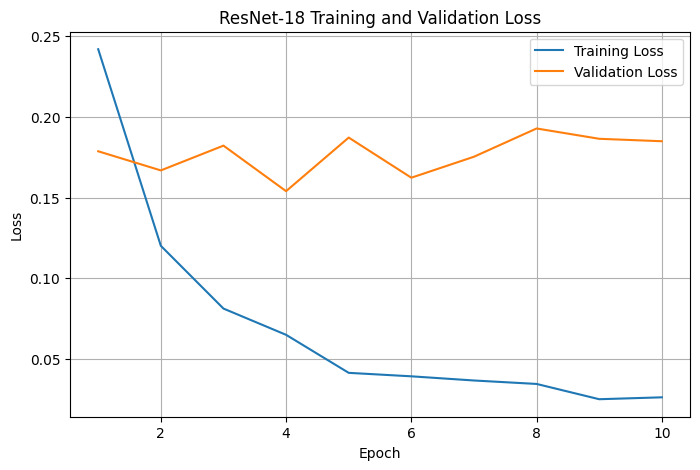

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), resnet_train_losses, label="Training Loss")
plt.plot(range(1, num_epochs + 1), resnet_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-18 Training and Validation Loss")
plt.legend()
plt.grid(True)

wandb.log({"Loss Curve": wandb.Image(plt)})
plt.show()
plt.close()

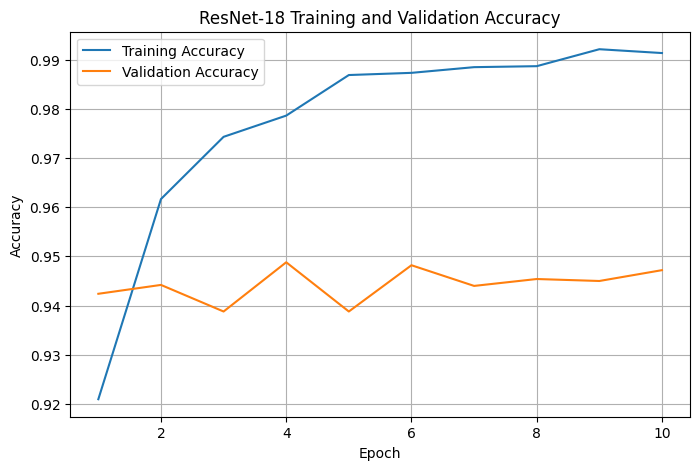

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), resnet_train_accuracies, label="Training Accuracy")
plt.plot(range(1, num_epochs + 1), resnet_val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet-18 Training and Validation Accuracy")
plt.legend()
plt.grid(True)

wandb.log({"Accuracy Curve": wandb.Image(plt)})
plt.show()
plt.close()

In [25]:
resnet_test_dataset = datasets.CIFAR10(
    root=base_dataset.root,
    train=False,
    download=False,
    transform=resnet_val_transform
)

resnet_test_loader = DataLoader(
    resnet_test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test samples:", len(resnet_test_dataset))
print("Test batches:", len(resnet_test_loader))

Test samples: 10000
Test batches: 157


In [26]:
import numpy as np

resnet_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in resnet_test_loader:
        images = images.to(device)

        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Predictions:", len(all_predictions))
print("Labels:", len(all_labels))

Predictions: 10000
Labels: 10000


<Figure size 900x800 with 0 Axes>

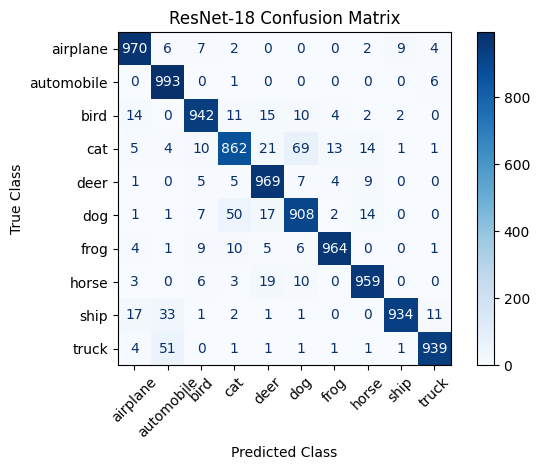

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(9, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("ResNet-18 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()

# Log to W&B
wandb.log({
    "Confusion Matrix": wandb.Image(plt)
})

plt.show()
plt.close()

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_accuracy = accuracy_score(all_labels, all_predictions)

precision_macro = precision_score(
    all_labels, all_predictions, average="macro"
)

recall_macro = recall_score(
    all_labels, all_predictions, average="macro"
)

f1_macro = f1_score(
    all_labels, all_predictions, average="macro"
)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Precision     : {precision_macro:.4f}")
print(f"Recall        : {recall_macro:.4f}")
print(f"F1 Score      : {f1_macro:.4f}")

Test Accuracy : 0.9440
Precision     : 0.9446
Recall        : 0.9440
F1 Score      : 0.9439


In [29]:
total_params = sum(
    p.numel() for p in resnet_model.parameters()
)

trainable_params = sum(
    p.numel() for p in resnet_model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 11,181,642
Trainable parameters: 11,181,642


In [30]:
wandb.log({
    "total_parameters": total_params,
    "trainable_parameters": trainable_params
})

In [31]:
wandb.finish()

epoch,▁▂▃▃▄▅▆▆▇█
epoch_time_seconds,█▄▇▂▁▄▅▅▂▆
total_parameters,▁
total_training_time_seconds,▁
train_accuracy,▁▅▆▇▇█████
train_loss,█▄▃▂▂▁▁▁▁▁
trainable_parameters,▁
val_accuracy,▄▅▁█▁█▅▆▅▇
val_loss,▅▃▆▁▇▃▅█▇▇
epoch,10
epoch_time_seconds,158.67303
